## Step 3: Natural Language Processing

Structured EHR codes aren’t the only source of clinical information. EHR freetext notes contain substantial clinical information. Using NLP, we can convert those notes into standardized concept codes (e.g., CUIs) so they can be integrated with the structured EHR data.

## Unified Medical Language System (UMLS)


UMLS is a collection of more than 200 health and biomedical vocabularies (e.g., ICD, SNOMED-CT, RxNorm, LOINC) developed and maintained by the U.S. National Library of Medicine to enable interoperability across systems. One of its central features, the Metathesaurus, maps synonymous terms from different vocabularies to a single **Concept Unique Identifier (CUI)** to support interoperability.


One can use the [UMLS Browser](https://uts.nlm.nih.gov/uts/umls/concept/C0011849) to search for “Diabetes mellitus.” It will display a concept page similar to the one shown below.

![Screenshot 2025-10-01 at 8.18.13 PM.png](<attachment:Screenshot 2025-10-01 at 8.18.13 PM.png>)

The UMLS provides mappings from terms to Concept Unique Identifiers (CUIs) for a wide range of biomedical concepts. Couple of examples are shown below.

| Name                         | CUI      | AUI       | Vocabulary   | Term Type | Code      |
|---|---|---|---|---|---|
| DIABETES MELLITUS            | C0011849 | —         | WHO          | PT        | 0371      |
| Diabetes mellitus            | C0011849 | A2928669  | SNOMEDCT_US  | PT        | 73211009  |
| Bronchial Asthma             | C0004096 | A26667996 | MSH          | ET        | D001249   |
| Asthma                       | C0004096 | A2878777  | SNOMEDCT_US  | PT        | 195967001 |
| Hypertension                 | C0020538 | A0070978  | MSH          | MH        | D006973   |
| Blood Pressure, High         | C0020538 | A26603831 | MSH          | ET        | D006973   |


 If you have a clinical note like below, you can process the note using a dictionary of CUI-term mappings to convert it a sequence of CUIs

**Example: Mapping clinical note text to CUIs**

Given a note:

| patient_id | date       | note                                                                                  |
|---|---|---|
| 10001      | 2012-12-12 | The patient was admitted to the hospital due to asthma. He has a secondary diagnosis of DM – Diabetes mellitus. Discharge Diagnosis: Hypertension |

After dictionary lookup, the extracted concepts and CUIs might be:

| patient_id | date       | extracted_terms                            | mapped_CUIs                 |
|---|---|---|---|
| 10001      | 2012-12-12 | asthma; DM – Diabetes mellitus;Hypertension| C0004096;C0011849;C0020538          |



Several tools are available for performing this text to code converstion:

1. **[cTAKES](https://ctakes.apache.org/)** – An open-source NLP system developed by Apache, widely used for extracting information from clinical notes.  
2. **[NILE](https://celehs.hms.harvard.edu/software/NILE.html)** – A lightweight and efficient tool developed at Harvard for extracting UMLS concepts from text; recommended for most applications.  
3. **[MetaMap](https://lhncbc.nlm.nih.gov/ii/tools/MetaMap.html)** – A tool developed by the National Library of Medicine (NLM) that maps biomedical text to UMLS concepts.  
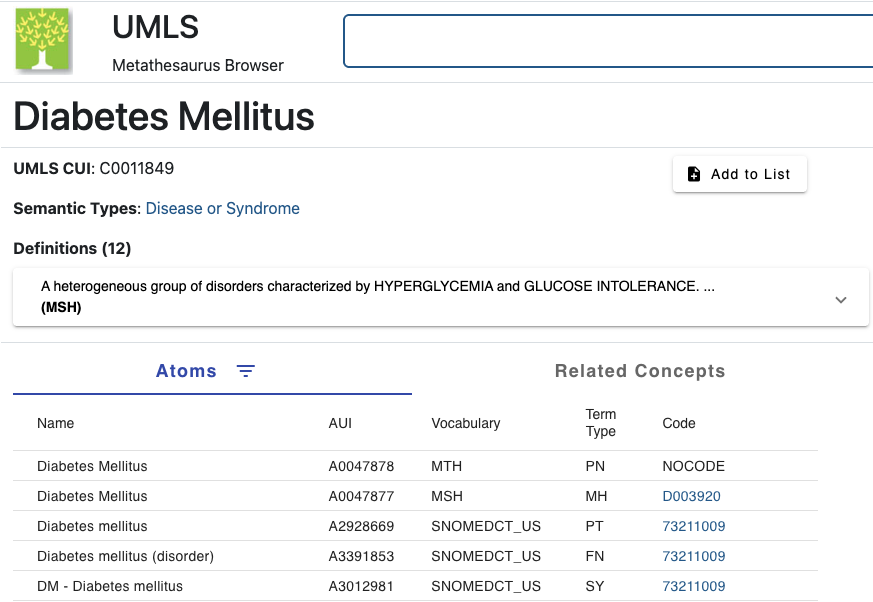

### Coverting Notes to Sequence of CUIs

For this tutorial, we analyze a random sample of MIMIC-IV discharge notes and process them using [Petehr](https://pypi.org/project/petehr/), a custom natural language processing (NLP) toolkit developed for this tutorial. For higher performance and production use, we recommend [NILE](https://celehs.hms.harvard.edu/software/NILE.html) or comparable software. 
We will illustrate the above example using petehr library

In [29]:
import pandas as pd
import numpy as np

# Build the rows (keep codes as strings to preserve leading zeros like "0371")
rows = [
    {"str": "DIABETES MELLITUS", "cui": "C0011849", "aui": None,        "vocabulary": "WHO",         "term type": "PT", "code": "0371"},
    {"str": "Diabetes mellitus", "cui": "C0011849", "aui": "A2928669",  "vocabulary": "SNOMEDCT_US", "term type": "PT", "code": "73211009"},
    {"str": "Bronchial Asthma",  "cui": "C0004096", "aui": "A26667996", "vocabulary": "MSH",         "term type": "ET", "code": "D001249"},
    {"str": "Asthma",            "cui": "C0004096", "aui": "A2878777",  "vocabulary": "SNOMEDCT_US", "term type": "PT", "code": "195967001"},
    {"str": "Hypertension",      "cui": "C0020538", "aui": "A0070978",  "vocabulary": "MSH",         "term type": "MH", "code": "D006973"},
    {"str": "Blood Pressure, High","cui": "C0020538","aui": "A26603831","vocabulary": "MSH",         "term type": "ET", "code": "D006973"},
]


df = pd.DataFrame(rows)

print(df)

                    str       cui        aui   vocabulary term type       code
0     DIABETES MELLITUS  C0011849       None          WHO        PT       0371
1     Diabetes mellitus  C0011849   A2928669  SNOMEDCT_US        PT   73211009
2      Bronchial Asthma  C0004096  A26667996          MSH        ET    D001249
3                Asthma  C0004096   A2878777  SNOMEDCT_US        PT  195967001
4          Hypertension  C0020538   A0070978          MSH        MH    D006973
5  Blood Pressure, High  C0020538  A26603831          MSH        ET    D006973


In [30]:
#Creating a cui-term dictionary

cui_dict = df[['str','cui']].copy()
cui_dict['str']= cui_dict['str'].str.lower()
cui_dict.drop_duplicates(inplace=True)
print(cui_dict)
cui_dict.to_csv("cui_dict.csv",index=None)

                    str       cui
0     diabetes mellitus  C0011849
2      bronchial asthma  C0004096
3                asthma  C0004096
4          hypertension  C0020538
5  blood pressure, high  C0020538


In [31]:
from petehr import Text2Code

mapper = Text2Code("cui_dict.csv")
note = "The patient was admitted to the hospital due to asthma and taken to ICU. He has a secondary diagnosis of DM – Diabetes mellitus and hypertension "
print("Original Note:", note)
codes = mapper.convert(note.lower())
print("Concepts identified from the notes:", codes)

Dictionary loaded sucessfully from cui_dict.csv
Original Note: The patient was admitted to the hospital due to asthma and taken to ICU. He has a secondary diagnosis of DM – Diabetes mellitus and hypertension 
Concepts identified from the notes: C0004096,C0011849,C0020538


### Building the CUI-term Dictionary

To transform freetext notes into analyzable concepts, we map terms in the text to **UMLS Concept Unique Identifiers (CUIs)** using a term to CUI dictionary. Two practical pathways are outlined below.

#### Option A: Build a comprehensive term to CUI dictionary from UMLS

The UMLS Metathesaurus provides the table **`MRCONSO.RRF`**, which contains lexical variants, synonyms, and source vocabulary terms linked to CUIs. You can download the UMLS release from the National Library of Medicine:

- UMLS Knowledge Sources: https://www.nlm.nih.gov/research/umls/licensedcontent/umlsknowledgesources.html

The raw cui-term mappings are really noisy, so we encourage you to do addtional cleaning

**Recommended extraction filters (for English clinical use):**
- **Language**: `LAT='ENG'`
- **Suppressible flag**: exclude rows with `SUPPRESS='Y'` 
- **Source vocabularies**:  We typically include all vocabularies to create a global dictionary for all purposes.


**High-level workflow:**
1. **Extract**: Load `MRCONSO.RRF` and filter as above.  
2. **Normalize**: Lowercase, and optionally strip punctuations in `STR` column.  
3. **Stopwords**: Remove stopwords from the CUI-Term mappings.
4. **Deduplicate**: Remove redundant mappings between CUIs and Concepts.
5. **Restrict**: This is optional, depending on the downstream taks, you can filter the CUIs to only keep clinically relevant semantic types (e.g., Disease or Syndrome, Finding, Pharmacologic Substance) for your use case. This can be done using the `MRREL.RRF` table in UMLS.


---

#### Option B: Use ONCE for obtaining condition focused dictionaries

If your project centers on specific conditions (e.g., diabetes, asthma), you may prefer a lightweight approach:

[**ONCE** (Online Narrative and Codified feature Search Engine)](https://shiny.parse-health.org/ONCE/) is a feature generation search engine that, given a target disease, identifies related **narrative** and **codified** EHR features for downstream analysis.

**How to use ONCE**

1. Search for the condition of interest (e.g., “Diabetes mellitus”).
2. Review the returned concepts and synonyms.
3. Download the CUI-term mappings for that condition.
4. Integrate these mappings into your text-processing pipeline (you can combine multiple condition-specific dictionaries if needed).

**When to prefer ONCE**

- Rapid prototyping, phenotype specific studies, or any settings where a smaller, high-precision dictionary is sufficient.
- Situations where full UMLS processing is impractical due to time or infrastructure constraints or noisy output.


A complete tutorial notebook detailing the NLP pipeline for sample discharge notes is available [here](https://github.com/celehs/PEHRT/blob/main/TUTORIAL/EHR_Preprocessing_3_Natural_Language_Processing.ipynb) 

To access the full collection of tutorial notebooks, tools, visualizations, and relevant metadata files, please register [here](https://harvard.az1.qualtrics.com/jfe/form/SV_6WJERAowyHA9by6)